Leitura dos dados no disco

In [1]:
# ambiente anaconda
import sys
print(sys.executable) # orange3 ou youtube

/home/fabiene/anaconda3/envs/orange3/bin/python


In [2]:
import sys
print(sys.version)


3.10.18 (main, Jun  5 2025, 13:14:17) [GCC 11.2.0]


In [3]:
!conda list


# packages in environment at /home/fabiene/anaconda3/envs/orange3:
#
# Name                    Version                   Build  Channel
_libgcc_mutex             0.1                        main  
_openmp_mutex             5.1                       1_gnu  
_py-xgboost-mutex         2.0                       cpu_0    conda-forge
accelerate                1.12.0                   pypi_0    pypi
aiohappyeyeballs          2.6.1                    pypi_0    pypi
aiohttp                   3.13.2                   pypi_0    pypi
aiosignal                 1.4.0                    pypi_0    pypi
anyio                     4.11.0             pyhcf101f3_0    conda-forge
anyqt                     0.2.1              pyhd8ed1ab_0    conda-forge
aom                       3.9.1                hac33072_0    conda-forge
argon2-cffi               21.3.0             pyhd3eb1b0_0  
argon2-cffi-bindings      25.1.0          py310hee96239_0  
asttokens                 3.0.0              pyhd8ed1ab_1    conda-f

In [4]:
import subprocess

# Executa o comando e captura o texto resultante
resultado = subprocess.check_output(["conda", "list"]).decode("utf-8")
print(resultado)

# packages in environment at /home/fabiene/anaconda3/envs/orange3:
#
# Name                    Version                   Build  Channel
_libgcc_mutex             0.1                        main  
_openmp_mutex             5.1                       1_gnu  
_py-xgboost-mutex         2.0                       cpu_0    conda-forge
accelerate                1.12.0                   pypi_0    pypi
aiohappyeyeballs          2.6.1                    pypi_0    pypi
aiohttp                   3.13.2                   pypi_0    pypi
aiosignal                 1.4.0                    pypi_0    pypi
anyio                     4.11.0             pyhcf101f3_0    conda-forge
anyqt                     0.2.1              pyhd8ed1ab_0    conda-forge
aom                       3.9.1                hac33072_0    conda-forge
argon2-cffi               21.3.0             pyhd3eb1b0_0  
argon2-cffi-bindings      25.1.0          py310hee96239_0  
asttokens                 3.0.0              pyhd8ed1ab_1    conda-f

In [5]:
import torch
import torchvision
import matplotlib
import PIL

print(f"PyTorch: {torch.__version__}")
print(f"Torchvision (Processa as imagens): {torchvision.__version__}")
print(f"Matplotlib (Gera os gráficos): {matplotlib.__version__}")
print(f"Pillow (Lê os pixels): {PIL.__version__}")

PyTorch: 2.9.1+cpu
Torchvision (Processa as imagens): 0.24.1+cpu
Matplotlib (Gera os gráficos): 3.10.6
Pillow (Lê os pixels): 11.3.0


# Projeto 14: Rede Neural Convolucional Gatos e Cachorros

## Etapa 1: Importação das bibliotecas

In [6]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
import zipfile
torch.__version__

'2.9.1+cpu'

In [7]:
torch.manual_seed(123) # para sempre termos o mesmo resultado

## Etapa 2: Construção do modelo

kernel = 3

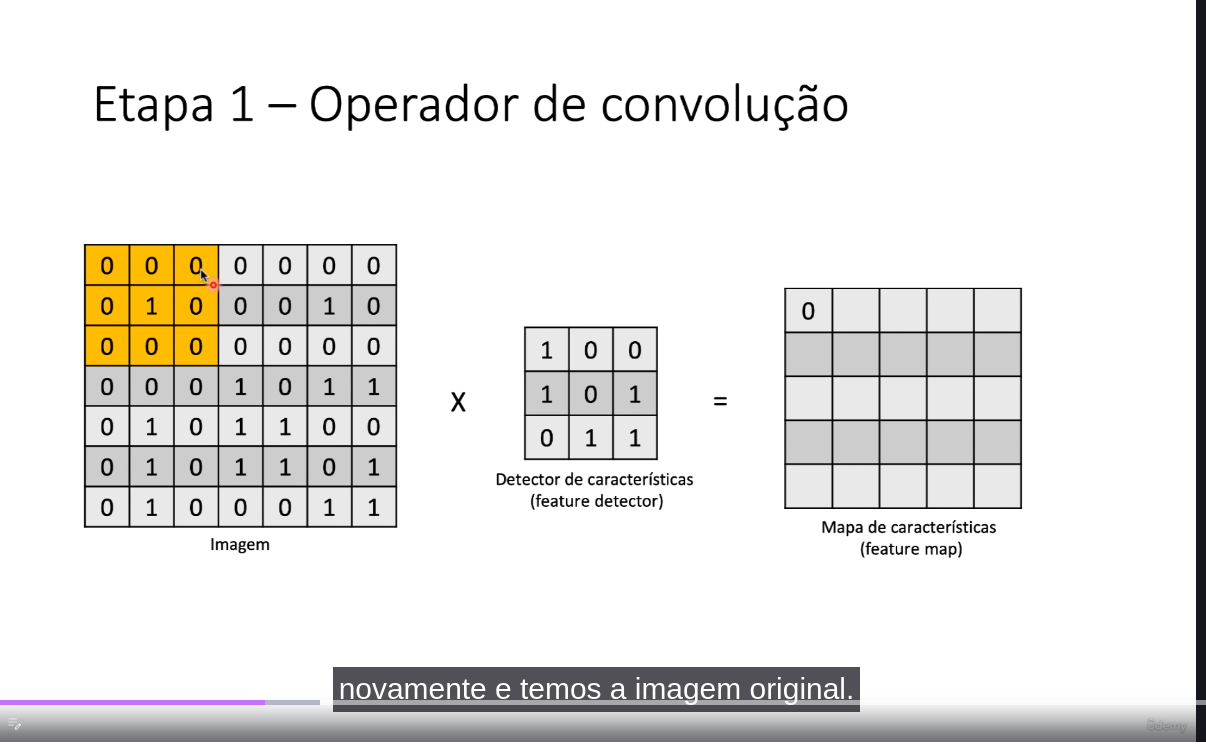

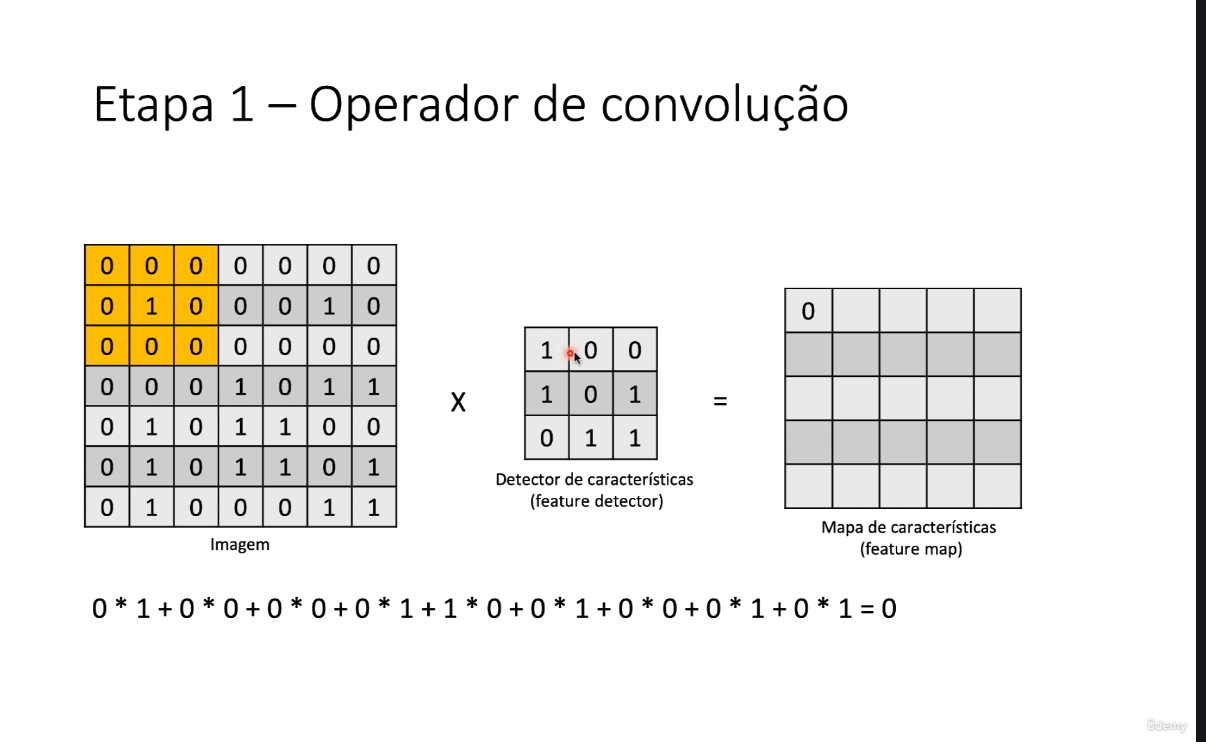

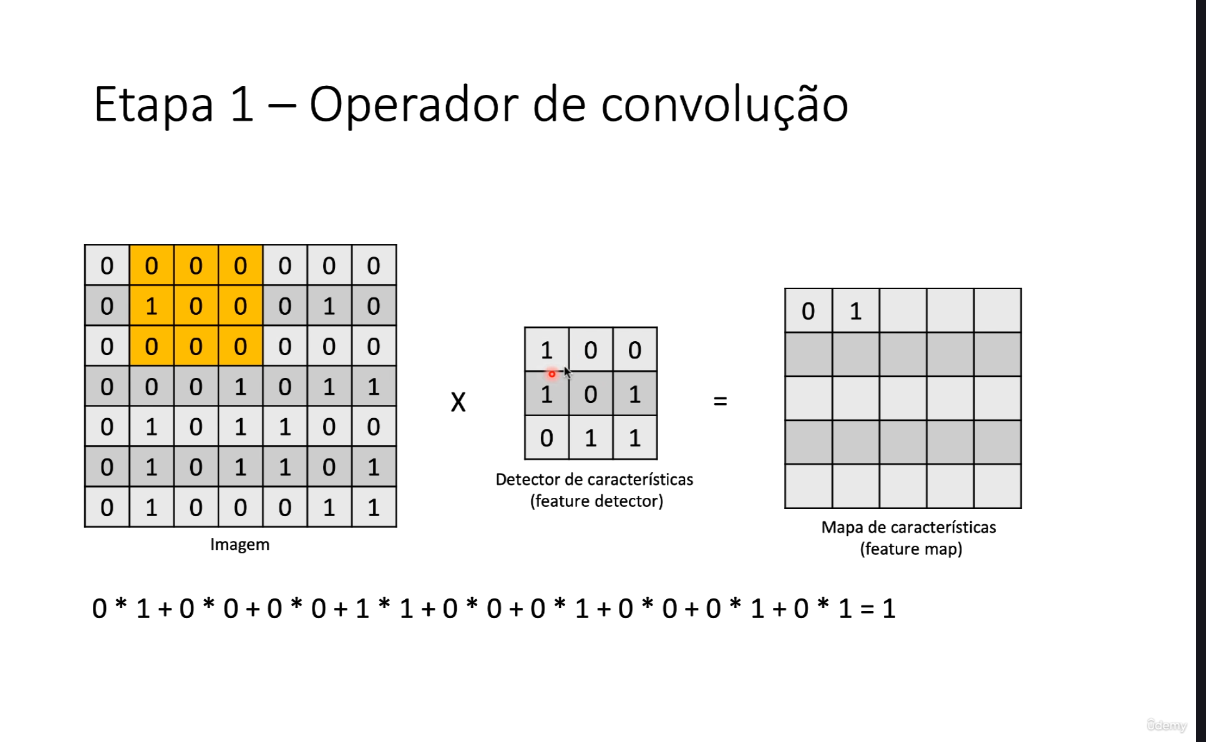

deslocando pixel a pixel
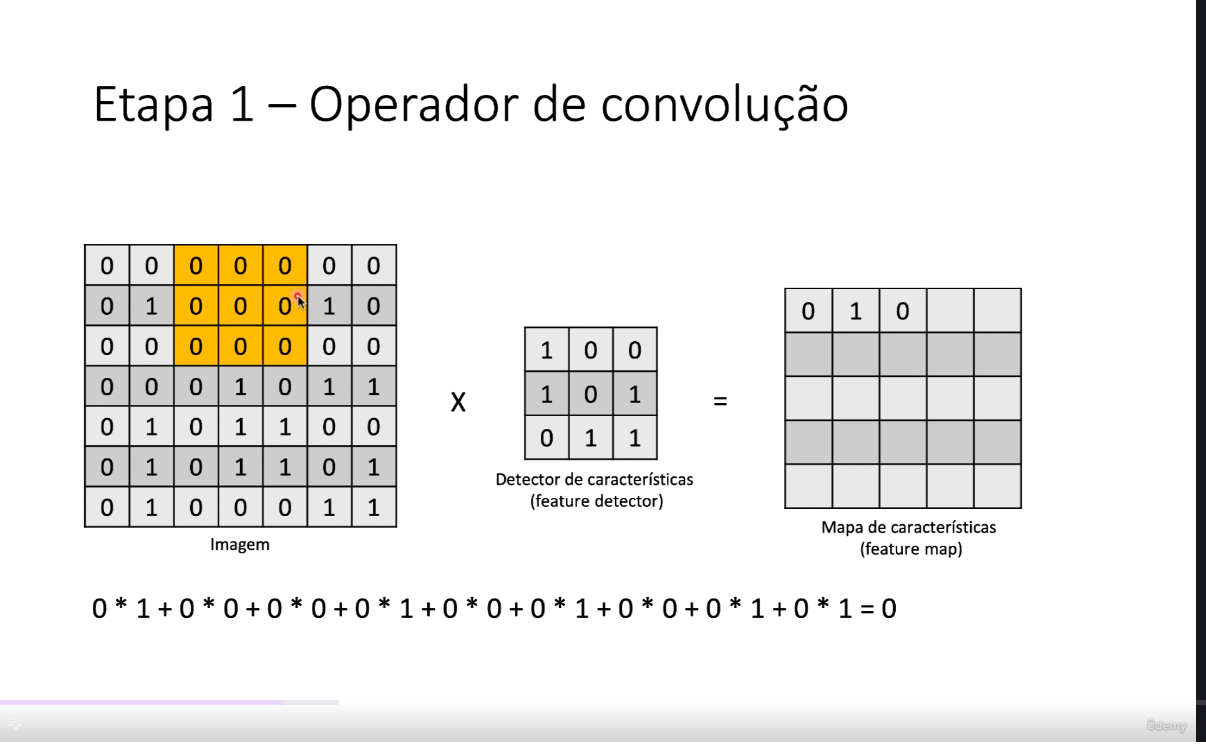

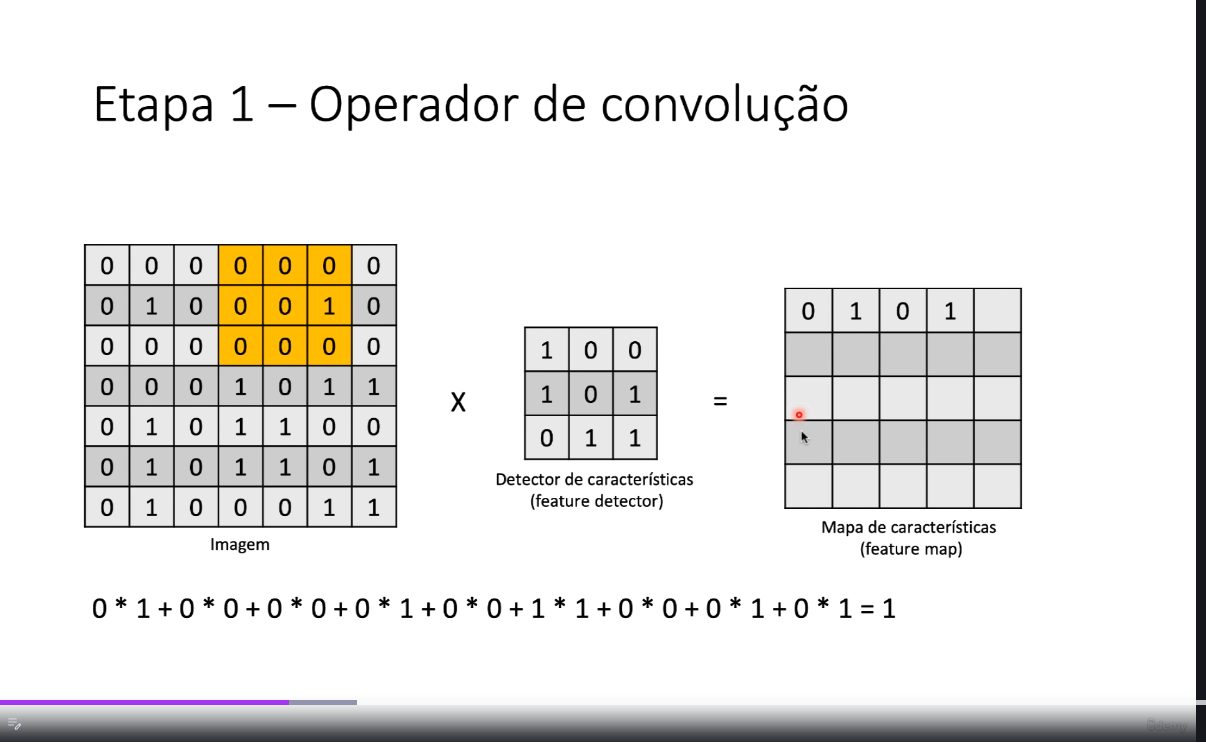

## Comando ReLU()

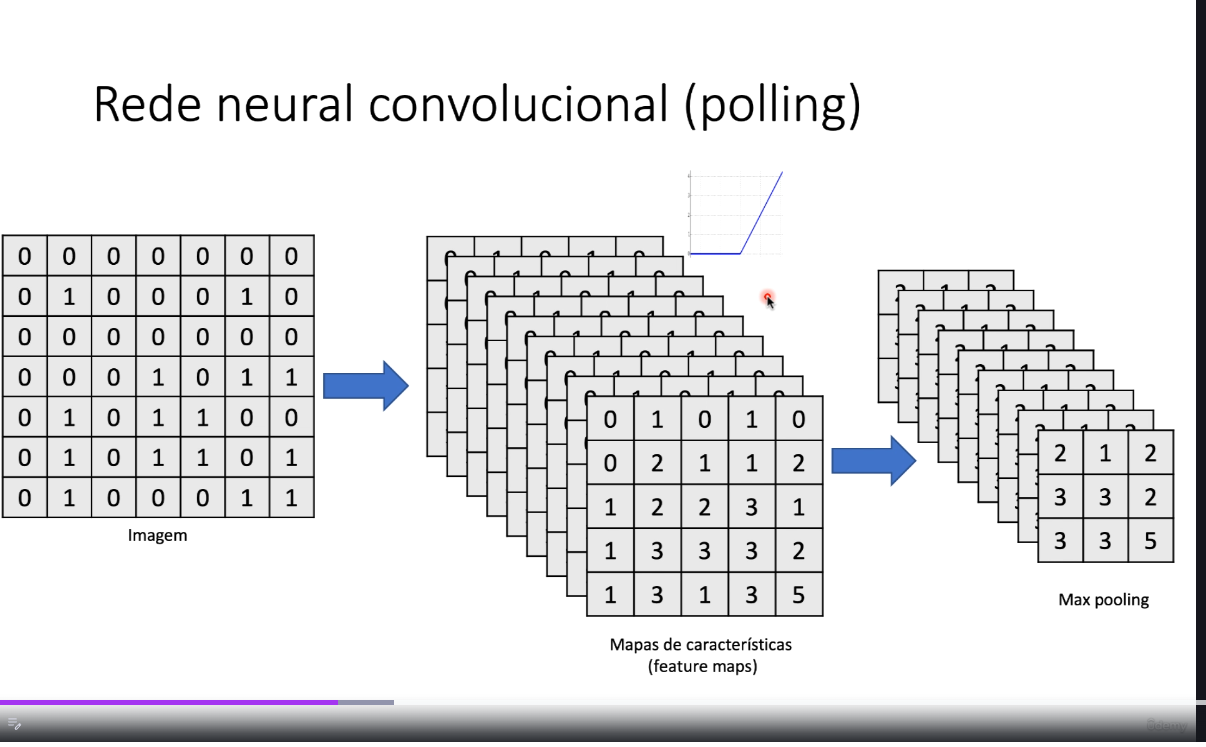

## MaxPool2d, escolha dos maiores valores


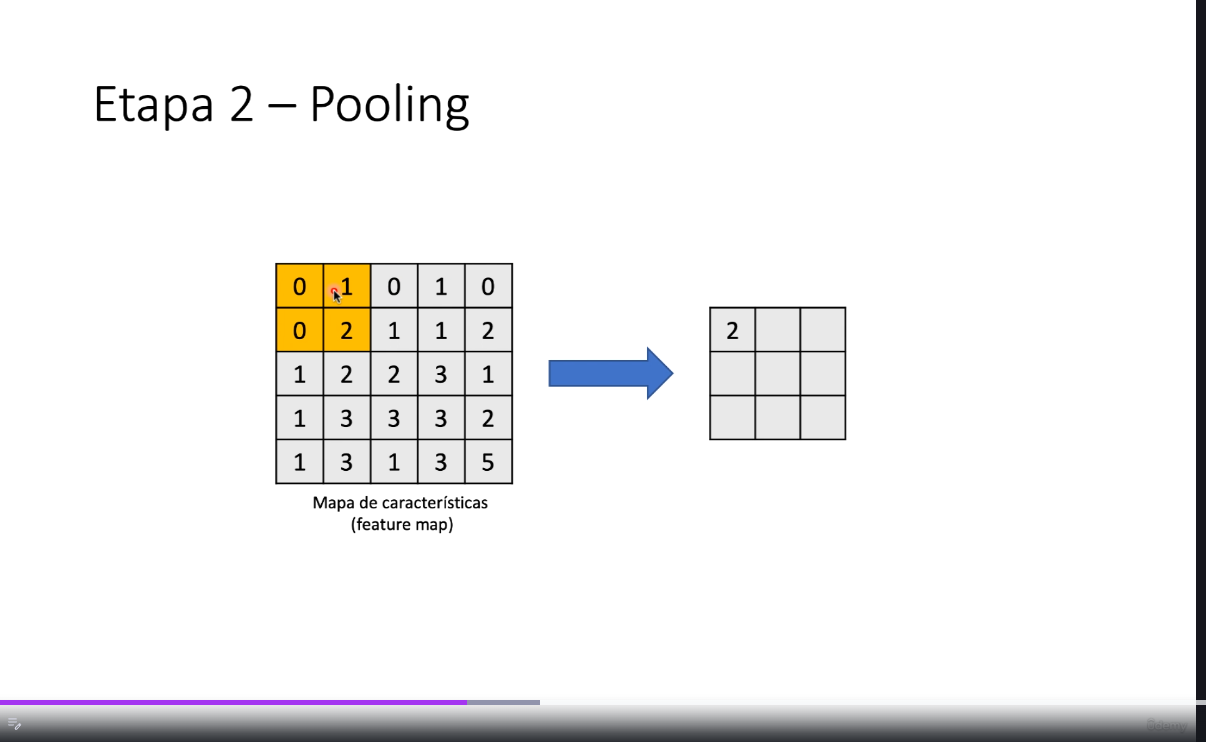


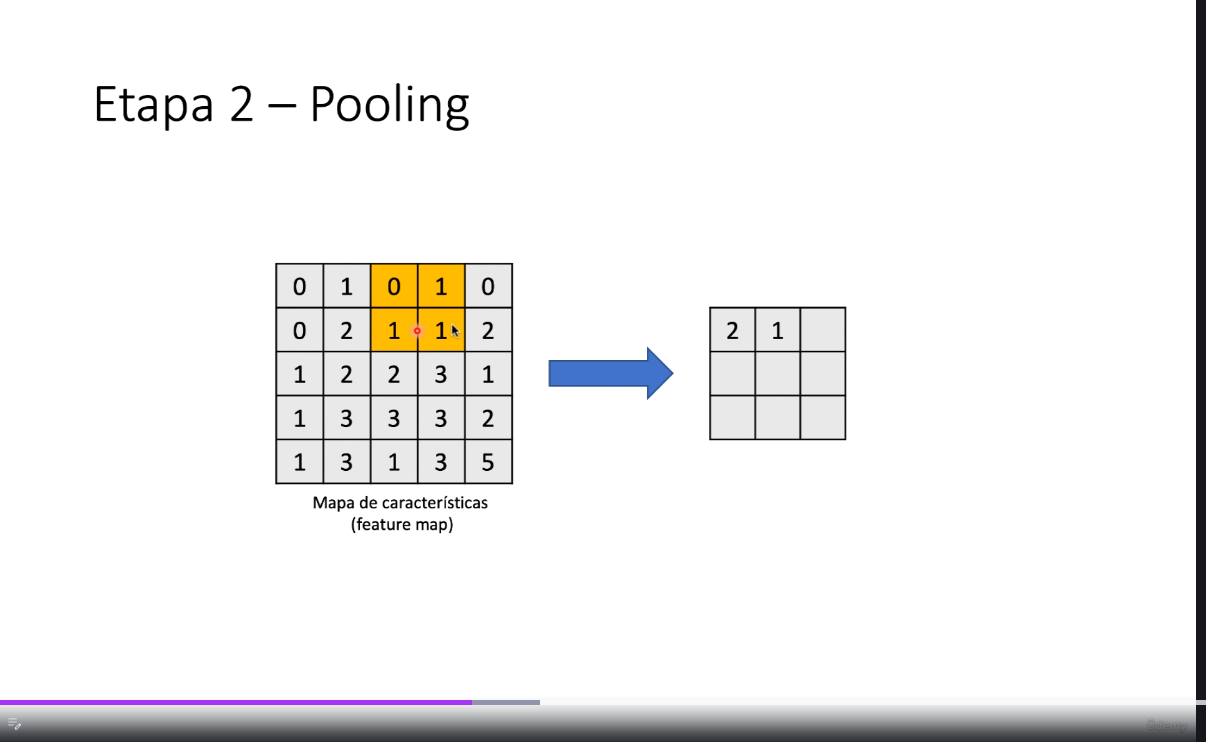


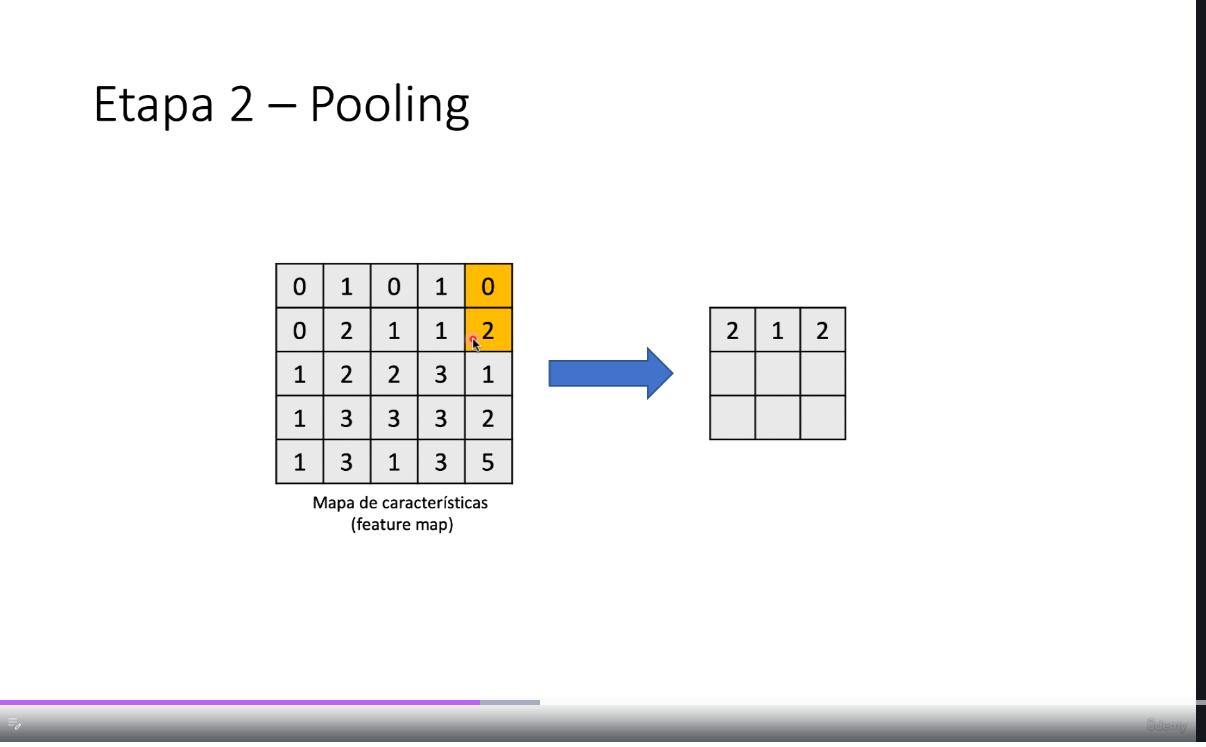

In [8]:
# Definindo a arquitetura como uma sequência linear de camadas
# output = (input - filter + 1) / stride

# a nossa imagem definimos abaixo como 64x64 pixels no transform_train, tanto para o treino como para o teste
# 1. Redimensiona a imagem para 64x64 pixels (necessário para entrar na sua rede)
#transforms.Resize([64, 64]),

classificador = nn.Sequential(
                             # 1. CONVOLUÇÃO: Entrada 3 canais (RGB), Saída 32 mapas. Kernel 3x3 reduz 2 pixels (64-3+1 = 62)
                              #camada convolucional com canal de cores, por isso 3 RGB, vermelho, verde e azul
                              # 32 filtros no out_channels, matriz 3x 3 no kernel_size
                              nn.Conv2d(in_channels=3, out_channels=32, kernel_size = 3),
                              nn.ReLU(), # Ativação: Mantém positivos, zera negativos
                              # BatchNorm2d: Normalização: Estabiliza os dados para o treino ser mais rápido
                              # normalização nas camadas ocultas, no num_features igual ao número dos filtroa
                              nn.BatchNorm2d(num_features=32),
                               # stride é de quantos em quantos o pixels vai andando, no caso 1
                              ## output = (input - filter + 1) / stride 
                              # (64 - 3 + 1) / 1 = 62x62

                              # 2. POOLING: Reduz a dimensão espacial pela metade (62 / 2 = 31)
                              nn.MaxPool2d(kernel_size = 2), # Resultado: 32 mapas de 31x31

                              # 3. CONVOLUÇÃO: Recebe 32, solta 32. Kernel 3x3 reduz mais 2 pixels (31-3+1 = 29)
                              # 31x31
                              nn.Conv2d(32, 32, 3),
                              nn.ReLU(),
                              nn.BatchNorm2d(32),
                              ## output = (input_novo - filter + 1) / stride 
                              # (31 - 3 + 1) / 1 = 29x29

                              # 4. POOLING: Reduz novamente (29 / 2 = 14.5 -> Arredonda para 14)
                              nn.MaxPool2d(2), # tamanho o filtro também será 2x2 (tamanho da matriz)
                              # MaxPool2d(2) => Resultado: 32 mapas de 14x14
                              #  14x14
                              # 5. FLATTEN: Transforma a matriz 3D (32, 14, 14) em um vetor 1D de 6272 elementos
                              nn.Flatten(), # última parte, converter a matriz para 1 vetor
                              # 6272 -> 128 -> 128 -> 1
                    
                              # 6. LINEAR 1: Recebe o vetor de 6272 e conecta a 128 neurônios
                              # converter para rede neural densa
                              # valor do 14*14*32 => # output = (input - filter + 1) / stride 2 vezes acima
                              # seria 14x 14 que seria 14 linhas 14 colunas e multipicados também por 32, números dos filtros
                              # 14*14*32=6272 neurônios de entrada-> 128 -> 128 -> 1
                              nn.Linear(in_features=14*14*32, out_features=128),
                              nn.ReLU(),
                              # "Apaga" 20% da camada para evitar que a rede fique 'viciada' em detalhes inúteis.
                              # Overfitting (quando a rede apenas "decora" o banco de dados de treino mas falha feio na vida real).
                              nn.Dropout(0.2), # 20% dos neurônios serão zerados

                              # 7. LINEAR 2: Camada oculta extra com 128 neurônios
                              nn.Linear(128, 128),
                              nn.ReLU(),
                              nn.Dropout(0.2),
    
                              # 8. SAÍDA: Reduz para 1 neurônio final (Classificação Binária)
                              nn.Linear(128, 1), # saída um, pois só queremos classificar gatos ou cachorros.

                              # 9. SIGMOID: Transforma o resultado em uma probabilidade entre 0 e 1 (ex: 0.8 = 80% de chance)
                              nn.Sigmoid() # função sigmoid
                             # Converte a saída final em um valor entre 0 e 1 (ideal para sim/não)

                           )

fatten()

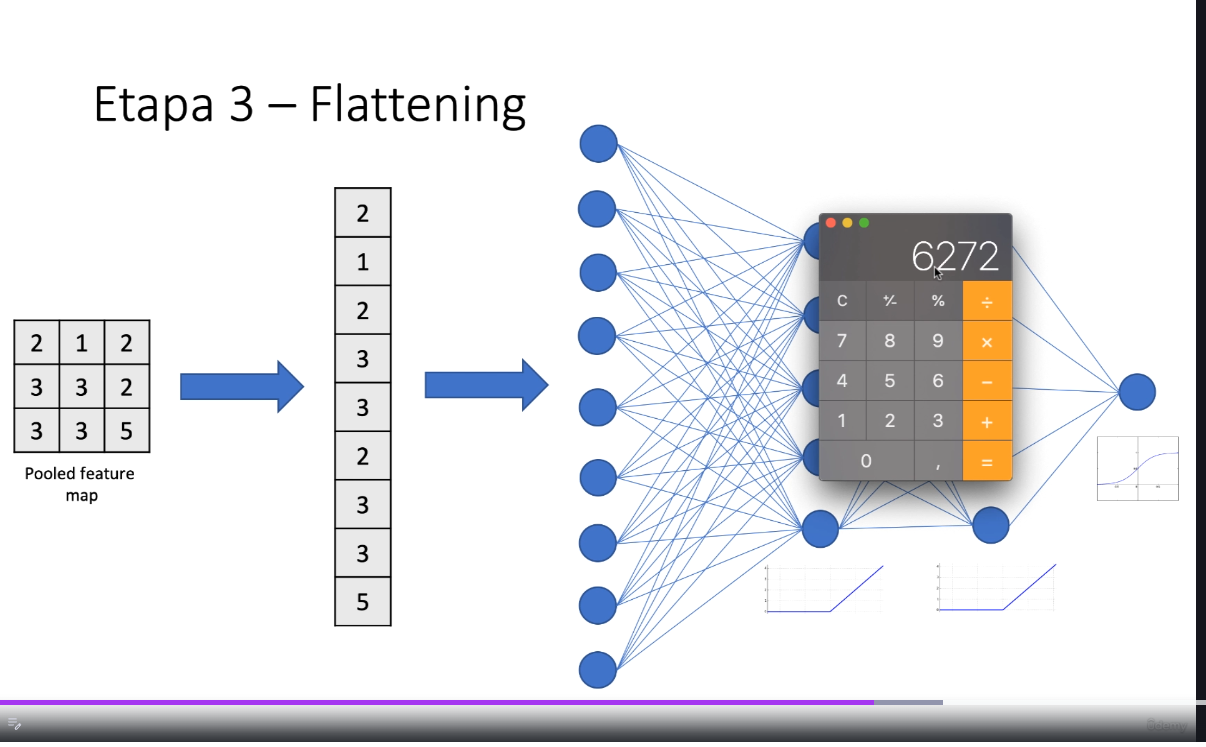

A função Sigmoid é uma das funções de ativação mais clássicas do Deep Learning. Ela atua como um "esmagador" de números, pegando qualquer valor (seja $-1000$ ou $+1000$) e forçando-o a ficar dentro de um intervalo fixo entre 0 e 1.

na rede neural:

A fórmula da Sigmoid é:$$f(x) = \frac{1}{1 + e^{-x}}$$Se o neurônio gera um número muito alto, a Sigmoid entrega algo próximo de 1.Se o neurônio gera um número muito baixo (negativo), ela entrega algo próximo de 0.Se o valor for 0, ela entrega exatamente 0.5.

Transformar em Probabilidade: Como o resultado está entre 0 e 1, você pode interpretar a saída como uma porcentagem.Exemplo: 0.85 significa "85% de chance de ser a classe positiva".Classificação Binária: Ela é o padrão ouro para problemas de "Sim ou Não".Se a saída for $> 0.5$, você classifica como Classe A.Se for $< 0.5$, como Classe B.

# feito a construção do modelo 

In [9]:
criterion = nn.BCELoss() # A régua que mede o erro para problemas de Sim/Não.
optimizer = optim.Adam(classificador.parameters()) # O mecanismo que ajusta os pesos para diminuir o erro.

1. criterion = nn.BCELoss()
O Medidor de Erro Binário

O que significa: Binary Cross Entropy Loss (Perda de Entropia Cruzada Binária).

O que faz: Ela calcula a diferença entre a probabilidade que a rede previu (ex: 0.8) e o rótulo real (0 ou 1).

Por que usar aqui: É a função obrigatória quando sua saída é um único neurônio com Sigmoid. Ela é muito eficiente em "empurrar" os valores para perto de 0 ou 1 durante o treino.

2. optimizer = optim.Adam(classificador.parameters())
O Motor de Ajuste Inteligente

O que faz: O Adam é o algoritmo que atualiza os pesos (neurônios) da sua rede baseando-se no erro calculado pelo BCELoss.

classificador.parameters(): Você está entregando ao Adam a "chave" dos neurônios do seu modelo para que ele possa ajustá-los.

Por que o Adam? Ele é famoso por ser "inteligente". Ele ajusta a taxa de aprendizado (learning rate) para cada parâmetro individualmente. Se um neurônio precisa de um ajuste grande e outro de um ajuste fino, o Adam faz isso automaticamente.

## Etapa 3: Base de dados

colar o código de acesso 

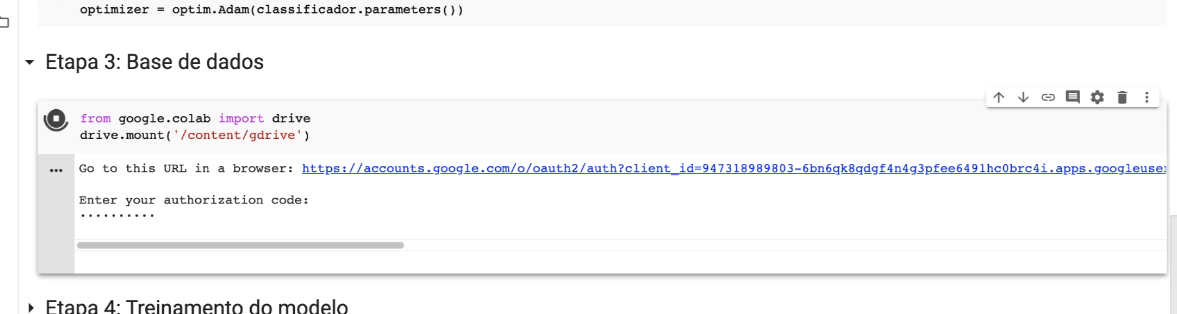

In [10]:
# from google.colab import drive
# drive.mount('/content/gdrive')

## descompactar o arquivo

In [11]:
#path = '/content/gdrive/My Drive/dataset.zip'
path = 'dataset.zip'
zip_object = zipfile.ZipFile(file = path, mode = 'r') # mode = r de read, leitura
zip_object.extractall('./') # extrair no diretorio raiz
#O './' significa diretório atual. Ou seja, ele vai extrair na mesma pasta onde seu script está rodando.
zip_object.close()

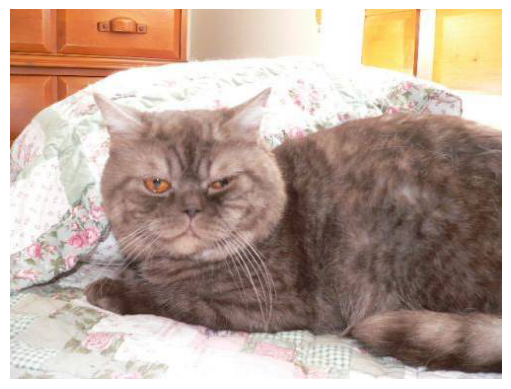

Tamanho da imagem: (499, 375)
Formato: JPEG


In [12]:
from PIL import Image
import matplotlib.pyplot as plt

# caminho do arquivo (diretório Linux)
caminho = '/home/fabiene/Documentos/Fabiene/UDEMY_ML/DeepLearning_AZ/Machine_LearningPyTorch/Modulo9_Classificacao_gatoseCachorros/dataset/test_set/gato/cat.3509.jpg'

# Abrindo a imagem
img = Image.open(caminho)

# Exibindo para conferir
plt.imshow(img)
plt.axis('off') # Remove as coordenadas do gráfico
plt.show()

# Verificando detalhes técnicos
print(f"Tamanho da imagem: {img.size}") # Largura x Altura
print(f"Formato: {img.format}")

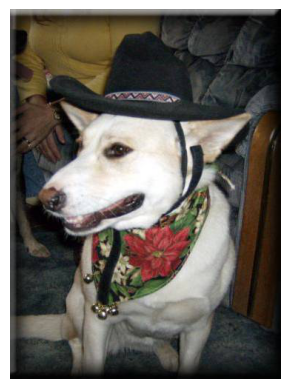

Tamanho da imagem: (366, 500)
Formato: JPEG


In [13]:
from PIL import Image
import matplotlib.pyplot as plt

# caminho do arquivo (diretório Linux)
caminho = '/home/fabiene/Documentos/Fabiene/UDEMY_ML/DeepLearning_AZ/Machine_LearningPyTorch/Modulo9_Classificacao_gatoseCachorros/dataset/test_set/cachorro/dog.3511.jpg'

# Abrindo a imagem
img = Image.open(caminho)

# Exibindo para conferir
plt.imshow(img)
plt.axis('off') # Remove as coordenadas do gráfico
plt.show()

# Verificando detalhes técnicos
print(f"Tamanho da imagem: {img.size}") # Largura x Altura
print(f"Formato: {img.format}")

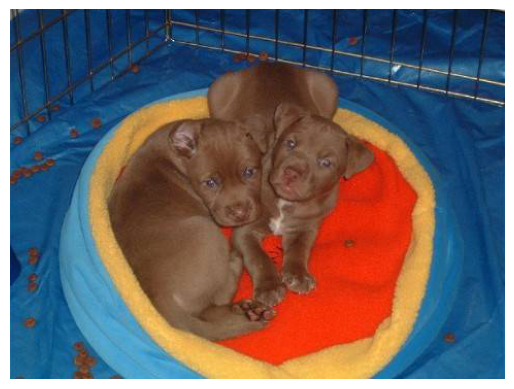

Tamanho da imagem: (480, 359)
Formato: JPEG


In [14]:
from PIL import Image
import matplotlib.pyplot as plt

# caminho do arquivo (diretório Linux)
caminho = '/home/fabiene/Documentos/Fabiene/UDEMY_ML/DeepLearning_AZ/Machine_LearningPyTorch/Modulo9_Classificacao_gatoseCachorros/dataset/test_set/cachorro/dog.3544.jpg'

# Abrindo a imagem
img = Image.open(caminho)

# Exibindo para conferir
plt.imshow(img)
plt.axis('off') # Remove as coordenadas do gráfico
plt.show()

# Verificando detalhes técnicos
print(f"Tamanho da imagem: {img.size}") # Largura x Altura
print(f"Formato: {img.format}")

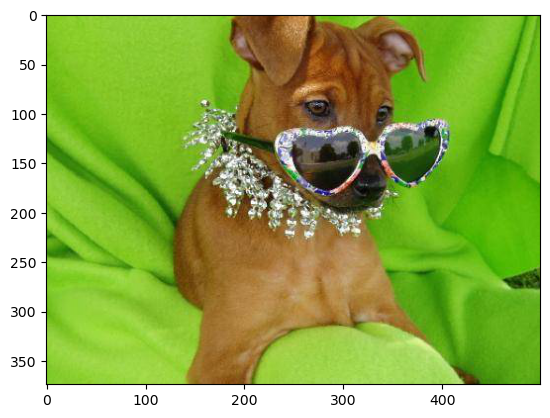

Tamanho da imagem: (500, 374)
Formato: JPEG


In [15]:
from PIL import Image
import matplotlib.pyplot as plt

# caminho do arquivo (diretório Linux)
caminho = '/home/fabiene/Documentos/Fabiene/UDEMY_ML/DeepLearning_AZ/Machine_LearningPyTorch/Modulo9_Classificacao_gatoseCachorros/dataset/test_set/cachorro/dog.3744.jpg'

# Abrindo a imagem
img = Image.open(caminho)

# Exibindo para conferir
plt.imshow(img)
#plt.axis('off') # Remove as coordenadas do gráfico
plt.show()

# Verificando detalhes técnicos
print(f"Tamanho da imagem: {img.size}") # Largura x Altura
print(f"Formato: {img.format}")

In [16]:
# receber os dados de treinamento

data_dir_train = 'dataset/training_set'
data_dir_test = 'dataset/test_set'

In [17]:
# criar um tranformador para a base de dados de treinamento
# leitura dos dados e fazer o treinamento

transform_train = transforms.Compose( # Agrupa várias transformações em uma única "receita"
    [
     # 1. Redimensiona a imagem para 64x64 pixels (necessário para entrar na sua rede)
     transforms.Resize([64, 64]),
     
     # 2. Inverte a imagem horizontalmente de forma aleatória (como um espelho)
     # Ajuda a rede a entender que um gato virado para a esquerda ainda é um gato.
     transforms.RandomHorizontalFlip(),
     
     # 3. Aplica distorções matemáticas (Afim):
     # degrees=7: Gira a imagem em até 7 graus. (rotacionar a imagem
     # translate: Move a imagem levemente para os lados ou para cima/baixo. (rotação na imagem)
     # shear: Inclina a imagem (deforma os ângulos). 
     # scale: Dá um zoom de até 20% (1.2) na imagem. (escala do zoom)
     transforms.RandomAffine(degrees=7, translate=(0, 0.07), shear=0.2, scale=(1, 1.2)),
     
     # 4. Transforma a imagem PIL (pixels 0-255) em um Tensor do PyTorch (0.0 a 1.0)
     transforms.ToTensor()
    ]
)


In [18]:
# transformador na base de teste

transform_test = transforms.Compose( # Agrupa os passos de preparação para as imagens de teste
    [
     # 1. Ajusta o tamanho da imagem para 64x64 pixels.
     # Todas as imagens que entrarem na rede precisam ter o mesmo tamanho do treino.
     transforms.Resize([64, 64]),

     # 2. Converte a imagem (que está em formato PIL/Pixels) para um Tensor do PyTorch.
     # Também muda a escala de cores de 0-255 para 0.0-1.0.
     transforms.ToTensor()
    ]
)

In [19]:
# criação da base de dados, leitura da imagem ImageFolder
# leitura das imagens e fazer as transformações
# ImageFolder: Cria o dataset mapeando automaticamente as pastas como classes (ex: 'gato' e 'cachorro')
# data_dir_train: O caminho no computador onde as pastas estão (/.../test_set/)
# transform: Aplica aquela "receita" de distorções (Resize, Flip, etc.) que definimos antes
train_dataset = datasets.ImageFolder(data_dir_train, 
                                     transform=transform_train
                                    )

In [20]:
# visualizar
train_dataset

Dataset ImageFolder
    Number of datapoints: 4000
    Root location: dataset/training_set
    StandardTransform
Transform: Compose(
               Resize(size=[64, 64], interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               RandomAffine(degrees=[-7.0, 7.0], translate=(0, 0.07), scale=(1, 1.2), shear=[-0.2, 0.2])
               ToTensor()
           )

In [21]:
# Dataset ImageFolder # imagem
    
# Number of datapoints: 4000 # número dos registros

# transformações que vai fazer: StandardTransform

# fazendo a normalização, trocar pixels por  valores entre 0 e 1

In [22]:
# treinamento de 32 a 32 registros, 
# shuffle true para misturar bem os dados

# DataLoader é quem organiza a entrega dessas imagens para o modelo durante o treinamento.
# DataLoader: Gerencia como os dados serão entregues ao modelo durante o treino
train_loader = torch.utils.data.DataLoader(
    train_dataset,    # O dataset que criamos com o ImageFolder
    batch_size = 32,  # Divide os dados em grupos de 32 imagens por vez
    shuffle = True    # Embaralha as imagens a cada nova época (ciclo de treino)
)


1. batch_size = 32 (O Tamanho do Lote)
A placa de vídeo (ou processador) raramente consegue processar todas as milhares de fotos de gatos e cachorros ao mesmo tempo.

O batch_size quebra o dataset em pedaços menores.

A rede olha para 32 imagens, calcula o erro médio delas, e só então ajusta os pesos (neurônios).

É um equilíbrio: lotes muito pequenos demoram para treinar; lotes muito grandes podem estourar a memória (VRAM).

2. shuffle = True (O Embaralhamento)
Isso é fundamental para o aprendizado!

Imagine que seu dataset tem 1000 fotos de gatos seguidas de 1000 de cachorros. Se não embaralhar, a rede vai "aprender" que tudo é gato no começo e depois vai "desaprender" para achar que tudo é cachorro no final.

O shuffle garante que cada lote de 32 imagens seja uma mistura aleatória, forçando a rede a realmente aprender a diferença entre os dois a cada passo.

#### Repetir os dados agora para o teste

In [23]:
test_dataset = datasets.ImageFolder(data_dir_test,
                                    transform=transform_test)

In [24]:
test_dataset

Dataset ImageFolder
    Number of datapoints: 1000
    Root location: dataset/test_set
    StandardTransform
Transform: Compose(
               Resize(size=[64, 64], interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )

In [25]:
#     Number of datapoints: 1000, número dos dados da base de teste


In [26]:
test_loader = torch.utils.data.DataLoader(test_dataset,
                                          batch_size = 32,
                                          shuffle=True)

## Etapa 4: Treinamento do modelo

In [27]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
device

device(type='cpu')

In [28]:
classificador.to(device)

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (1): ReLU()
  (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
  (5): ReLU()
  (6): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Flatten(start_dim=1, end_dim=-1)
  (9): Linear(in_features=6272, out_features=128, bias=True)
  (10): ReLU()
  (11): Dropout(p=0.2, inplace=False)
  (12): Linear(in_features=128, out_features=128, bias=True)
  (13): ReLU()
  (14): Dropout(p=0.2, inplace=False)
  (15): Linear(in_features=128, out_features=1, bias=True)
  (16): Sigmoid()
)

In [29]:
def training_loop(loader, epoch):
    # Inicializam os acumuladores para calcular a média no final da época
    running_loss = 0. # Soma das perdas (erro)
    running_accuracy = 0. # Soma da acurácia (acertos)

    # 'loader' divide os dados em pacotes (batches). 'enumerate' conta os loops.
    for i, data in enumerate(loader):
        # inputs pixels das imagens , e as respostas labels
        inputs, labels = data # Separa entrada (X) e resposta real (y)
        
        # Envia os dados para a GPU (se disponível) ou CPU (device)
        inputs, labels = inputs.to(device), labels.to(device)
        
        # 1. Zera a memória de gradientes anteriores (limpa o cache do erro anterior)
        # zerar os gradientes 
        # O gradiente é a direção para onde devemos ajustar os pesos para diminuir o erro.
        # optimizer.zero_grad() limpa os cálculos anteriores para não misturar erros novos com velhos.
        optimizer.zero_grad()
        
        # 2. Forward: O modelo faz a previsão baseada nos inputs atuais
        # classificar
        # retorna se é gato ou cachorro, um valor apenas
        # (15): Linear(in_features=128, out_features=1, bias=True)
        outputs = classificador(inputs)

        # 3. Calcula o erro (Loss) comparando o palpite (outputs) com a realidade (labels)
        # calculamos os erros, labels float => a função que calcula o loss BC(Binaru Cross) exige valores float
        loss = criterion(outputs, labels.float().view(*outputs.shape))
        # 4. Backward (Backpropagation): Calcula quanto cada 'neurônio' errou
        loss.backward()
        
        # 5. Step: O otimizador atualiza os pesos da rede para errar menos na próxima
        optimizer.step()
        # Acumula o valor do erro para o relatório final
        running_loss += loss.item()

        # Transforma a probabilidade (0 a 1) em classe binária: 1 se > 0.5, senão 0
        # for interno de classificações de 0 e 1, percorrendo a lista de outputs
        predicted = torch.tensor([1 if output > 0.5 else 0 for output in outputs]).to(device)

                # Verifica onde o modelo acertou (True) ou errou (False)
        # verificar se o previsor é igual ao dado real, e view é para deixar no mesmo formato que a previsão
        equals = predicted == labels.view(*predicted.shape)
        
        # Transforma os True/False em 1/0 e tira a média (ex: 0.85 de acurácia)
        # calcula a média da acurácia
        accuracy = torch.mean(equals.float())
        running_accuracy += accuracy
        # Imprime o progresso em tempo real na mesma linha (\r)
        # Imprimindo os dados referentes a esse loop
        print('\rÉPOCA {:3d} - Loop {:3d} de {:3d}: perda {:03.2f} - precisão {:03.2f}'.format(epoch + 1, i + 1, len(loader), loss, accuracy), end = '\r')
    # Ao final de todos os pacotes, imprime a média de erro e acerto da época inteira
    # Imprimindo os dados referentes a essa época
    print('\rÉPOCA {:3d} FINALIZADA: perda {:.5f} - precisão {:.5f}'.format(epoch + 1, running_loss/len(loader),
                    running_accuracy/len(loader)))


Gradiente é como uma "bússola" que indica a direção do erro. Ele é o conceito mais importante para o aprendizado de uma rede neural.

1. O que é o Gradiente?
Imagine que a sua rede neural está no topo de uma montanha em uma noite de neblina total. O objetivo dela é chegar no ponto mais baixo (onde o erro, ou loss, é zero).

Ela não consegue ver o caminho todo, então ela apalpa o chão ao redor dos pés para sentir a inclinação.

Essa inclinação é o Gradiente.

Se o gradiente é "alto", significa que o erro está mudando muito; se é "zero", a rede chegou ao fundo do vale (o melhor resultado possível).

Tecnicamente: O gradiente é o conjunto de derivadas parciais da função de erro em relação a cada peso (parâmetro) da rede. Ele diz: "Se você aumentar um pouquinho o peso do neurônio X, o erro vai subir ou descer?"

2. Por que e como zerar? (optimizer.zero_grad())
No PyTorch, os gradientes são acumulativos por padrão. Isso significa que, se você não limpá-los, o PyTorch vai somar o gradiente da rodada atual com o gradiente da rodada anterior.

O Problema de não zerar: Se você não rodar o zero_grad(), a rede vai ficar confusa. Seria como se você tentasse seguir a inclinação da montanha de hoje, mas ainda estivesse sentindo a inclinação da montanha que subiu ontem. O resultado? A bússola vai apontar para a direção errada e o modelo nunca vai aprender.

Como zerar: Você chama optimizer.zero_grad() logo no início de cada loop (ou logo antes de calcular o erro). Isso "limpa a lousa" para que o modelo calcule apenas o erro daquele pacote (batch) de dados específico.

optimizer.zero_grad(): Limpa a bússola (apaga o erro passado).

loss.backward(): Lê a bússola (calcula a inclinação atual do erro).

optimizer.step(): Dá um passo (ajusta os pesos na direção certa).

In [30]:
# Inicia um ciclo de 10 épocas (a rede verá todo o conjunto de dados 10 vezes)
for epoch in range(10):
    print('Treinando...') #treinando
    # 1. FASE DE APRENDIZADO   
    # Executa o loop de treino usando o carregador de dados de treinamento
    training_loop(train_loader, epoch)
    
    # modo de avaliação no treino, em modo de acurácia
    # 2. PREPARAÇÃO PARA TESTE
    # Coloca o modelo em modo de avaliação (eval). 
    # Isso desativa coisas como Dropout, garantindo previsões estáveis.    
    classificador.eval()
    
    print('Validando...') # testando, época a época
    # 3. FASE DE VALIDAÇÃO
    # Usa a mesma função, mas agora com os dados de teste para ver como a rede lida com o que é novo    
    training_loop(test_loader, epoch)
    # 4. RETORNO AO TRABALHO
    # Coloca o modelo de volta em modo de treinamento (train) para a próxima época.
    # Reativa camadas que ajudam no aprendizado (como Dropout e Batch Normalization).    
    # depois do treino de avaliação, é validado com o teste
    classificador.train() # s não colocar train, roda sempre em forma ou modo de teste e não faz a atualização dos pesos.

Treinando...
ÉPOCA   1 FINALIZADA: perda 0.64773 - precisão 0.632251
Validando...
ÉPOCA   1 FINALIZADA: perda 0.60700 - precisão 0.645510
Treinando...
ÉPOCA   2 FINALIZADA: perda 0.59396 - precisão 0.691006
Validando...
ÉPOCA   2 FINALIZADA: perda 0.57862 - precisão 0.706055
Treinando...
ÉPOCA   3 FINALIZADA: perda 0.55202 - precisão 0.713009
Validando...
ÉPOCA   3 FINALIZADA: perda 0.50882 - precisão 0.755868
Treinando...
ÉPOCA   4 FINALIZADA: perda 0.52585 - precisão 0.725509
Validando...
ÉPOCA   4 FINALIZADA: perda 0.43808 - precisão 0.787115
Treinando...
ÉPOCA   5 FINALIZADA: perda 0.50938 - precisão 0.751755
Validando...
ÉPOCA   5 FINALIZADA: perda 0.36051 - precisão 0.845700
Treinando...
ÉPOCA   6 FINALIZADA: perda 0.49619 - precisão 0.762259
Validando...
ÉPOCA   6 FINALIZADA: perda 0.35322 - precisão 0.857425
Treinando...
ÉPOCA   7 FINALIZADA: perda 0.46959 - precisão 0.767758
Validando...
ÉPOCA   7 FINALIZADA: perda 0.23201 - precisão 0.905270
Treinando...
ÉPOCA   8 FINALIZADA:

precisão ou acurácia ficou muito bom, próximo de 1

## Etapa 5: Avaliação do modelo

In [51]:
def classificar_imagem(fname): # nome da imagem fname
  # 1. PREPARAÇÃO VISUAL
  # biblioteca para visualizar as imagens no python  
  from PIL import Image
  import matplotlib.pyplot as plt
  # Abre a imagem usando o caminho completo (diretório + nome do arquivo)
  # leitura da imagem  , open(nome e local do arquivo)
  imagem_teste = Image.open(data_dir_test + '/' + fname)
  # carregar a imagem  
  # Exibe a imagem na tela para conferência do usuário
  plt.imshow(imagem_teste)

  import numpy as np
  # 2. PRÉ-PROCESSAMENTO (Padronização)
  # Redimensiona para 64x64 pixels (mesmo tamanho que a rede foi treinada) 
  # redefinir no mesmo padrão da rede neural  
  imagem_teste = imagem_teste.resize((64, 64))
  # Converte os pixels da imagem em um array numérico (Matriz) e organiza em (Altura, Largura, Cores)
  # imagem segue em numpy array  
  imagem_teste = np.array(imagem_teste.getdata()).reshape(*imagem_teste.size, 3)
  # Normalização: Converte valores de cor (0-255) para escala entre 0 e 1 (facilita o cálculo da rede)
  # normalizar os dados dividindo por 255. para converter de 0 e 1.  
  imagem_teste = imagem_teste / 255
  # imagem de teste recebe 2,0,1, para mudar as ordens das dimensões, primeiro batch size  
  # 3 tipos de canais de cores  
  # Transposição: Muda a ordem de (Altura, Largura, Canais) para (Canais, Altura, Largura)
  # O PyTorch exige que a cor (RGB) venha antes das dimensões da imagem
  imagem_teste = imagem_teste.transpose(2, 0, 1)
  # formato da imagem para o pytorch  
    
  # 3. CONVERSÃO PARA PYTORCH
  # Transforma o array numpy em um Tensor do PyTorch e adiciona uma dimensão extra para o 'batch'
  # O formato final fica: [1, 3, 64, 64] -> (1 imagem, 3 cores, 64x64 pixels)   
  imagem_teste = torch.tensor(imagem_teste, dtype=torch.float).view(-1, *imagem_teste.shape)

  # 4. INFERÊNCIA (Previsão)
  # Desativa camadas de treino (como Dropout) para ter uma previsão consistente
    
  # classificar em mode de avaliação  
  # Coloca o modelo em modo de avaliação (eval). 
  # Isso desativa coisas como Dropout, garantindo previsões estáveis.
  classificador.eval()
  # Move a imagem para a memória da GPU (se disponível) ou CPU
  # mandar para a gpu ou cpu
  imagem_teste = imagem_teste.to(device)
  # Passa a imagem pela rede neural para obter o resultado matemático
  # classificador passando a imagem de teste  
  output = classificador.forward(imagem_teste)
  # 5. PÓS-PROCESSAMENTO (Tradução do resultado)
  # Como a rede retorna um número entre 0 e 1 (Sigmoid), usamos 0.5 como ponto de corte    
  # verificar a previsão 1 ou 0, cão o gato  
  if output > 0.5:
    output = 1
  else:
    output = 0
  print('Previsão: ', output)
  # Mapeia o número (0 ou 1) de volta para o nome da classe (ex: 'cat' ou 'dog')
  #previsão no final
  idx_to_class = {value: key for key, value in test_dataset.class_to_idx.items()}
  print(idx_to_class)  
  # Retorna o nome da árvore/animal correspondente ao número previsto
  return idx_to_class[output]

Previsão:  1
{0: 'cachorro', 1: 'gato'}


'gato'

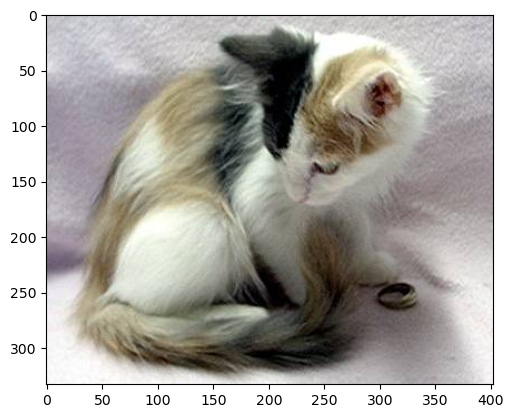

In [50]:
# fonte dos dados originais na pasta 'dataset/test_set'
#/home/fabiene/Documentos/Fabiene/UDEMY_ML/DeepLearning_AZ/Machine_LearningPyTorch/Modulo9_Classificacao_gatoseCachorros/dataset/test_set/gato
imagem = '/gato/cat.3500.jpg'
classificar_imagem(imagem)

In [45]:
data_dir_test

'dataset/test_set'

Previsão:  0
{0: 'cachorro', 1: 'gato'}


'cachorro'

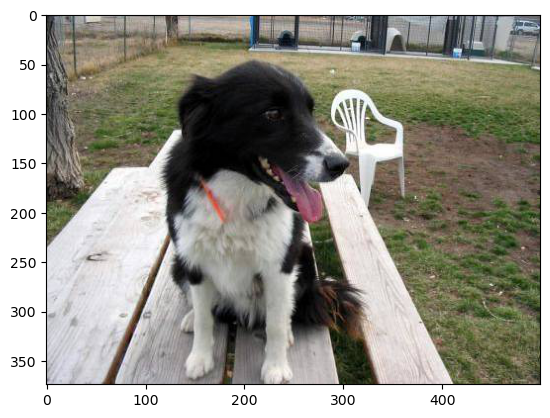

In [49]:
imagem = '/cachorro/dog.3502.jpg'
classificar_imagem(imagem)